# Taller — Construye y ajusta tu propio clasificador de imágenes

Este taller comienza **después de la teoría de CNN y del notebook guiado de transfer learning**.

La meta no es memorizar la API de Keras. La meta es tomar decisiones sobre un problema real: construir datos propios, adaptar un modelo preentrenado y analizar qué tan bien funciona.

---

## Organización de la actividad

| Momento | Tiempo estimado | Meta |
|---|---:|---|
| **Teoría + notebook guiado** | Se realiza antes de este taller | Comprender CNN, transfer learning y fine-tuning |
| **Trabajo en clase** | ~60 min | Construir el dataset y entrenar el primer modelo con la base congelada |
| **Trabajo en casa** | ~1–2 h | Evaluar, hacer fine-tuning, comparar y analizar errores |

### Regla importante

Durante el trabajo en clase usaremos **train** y **validation**.  
El conjunto de **test** se reservará para el trabajo en casa, cuando hagamos la evaluación final.

---

## Entrega final

Debes entregar **este mismo notebook ejecutado**, incluyendo:

- definición del problema y estrategia de búsqueda;
- dataset propio;
- primer entrenamiento con transfer learning;
- evaluación en test;
- fine-tuning;
- comparación antes/después;
- matriz de confusión;
- análisis de al menos 5 errores;
- conclusiones.

## 0. Preparación del entorno

La búsqueda de imágenes se realizará con `ddgs`. Si estás en Google Colab, ejecuta la siguiente celda.

In [1]:
!pip -q install -U ddgs


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

from pathlib import Path
import hashlib, io, random, shutil, time
import numpy as np
import matplotlib.pyplot as plt
import requests
from PIL import Image

import tensorflow as tf
import keras
from keras import layers
from ddgs import DDGS
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Keras:", keras.__version__)
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

Keras: 3.15.1
TensorFlow: 2.21.0
GPU: []


# PARTE A — TRABAJO EN CLASE (~60 min)

## Objetivo de esta parte

Antes de terminar la sesión debes haber conseguido:

1. definir un problema de clasificación de 3 clases;
2. descargar y revisar un dataset propio;
3. separar los datos en `train`, `validation` y `test`;
4. cargar EfficientNetB0 preentrenada en ImageNet;
5. congelar el backbone;
6. entrenar una nueva cabeza de clasificación;
7. observar `accuracy` y `val_accuracy`.

> **No evalúes todavía sobre `test`.** Ese conjunto queda reservado para el trabajo en casa.

### Distribución sugerida

- **10 min** — problema y términos de búsqueda;
- **20 min** — descarga, inspección y limpieza;
- **10 min** — separación y carga del dataset;
- **20 min** — transfer learning y primer entrenamiento.

# 1. Define tu problema — EN CLASE

Elige un problema de clasificación de **3 clases**. Las clases deben ser visualmente distinguibles.

Ejemplos: `espresso/cappuccino/latte`, `bus/motorcycle/bicycle`, tres especies de flores, frutas, tipos de calzado o instrumentos musicales.

Evita problemas donde la clase dependa de información que no aparece visualmente en la imagen.

## TODO 1 — Problema y estrategia de búsqueda

Define:

1. las tres clases;
2. dos o tres términos de búsqueda por clase;
3. una breve hipótesis: **¿qué características visuales esperas que use el modelo?**;
4. un posible sesgo o fuente de *data leakage* que podría aparecer al descargar imágenes desde un buscador.

In [3]:
# TODO 1 - EN CLASE: define tus clases y busquedas
# Problema: clasificar 3 tipos de bebida de cafe con leche/espuma, visualmente
# parecidas entre si (a proposito: es el ejemplo mas dificil que sugiere el
# enunciado, y permite un analisis de errores real en vez de una tarea trivial).
SEARCHES = {
    "espresso": [
        "espresso shot cup",
        "espresso coffee closeup",
    ],
    "cappuccino": [
        "cappuccino cup foam art",
        "cappuccino coffee cup",
    ],
    "latte": [
        "latte art cup",
        "latte macchiato cup",
    ],
}

SEARCHES


{'espresso': ['espresso shot cup', 'espresso coffee closeup'],
 'cappuccino': ['cappuccino cup foam art', 'cappuccino coffee cup'],
 'latte': ['latte art cup', 'latte macchiato cup']}

### Antes de descargar

Escribe debajo de esta celda una respuesta corta:

- ¿Qué características visuales esperas que diferencien tus clases?
- ¿Qué imágenes incorrectas esperas encontrar?
- ¿Qué sesgo o *data leakage* podría aparecer?

**Respuesta — TODO 1**

- **Por que este problema y no pizza/hamburguesa/sushi:** un primer intento con esas tres clases dio **100% de accuracy sin un solo error**, porque son clases demasiado distintas entre si y EfficientNetB0 ya las reconoce casi perfectamente desde ImageNet. Eso no deja nada que analizar en el TODO 6. Espresso/cappuccino/latte es justamente el ejemplo que sugiere el enunciado y es mas dificil: las tres son cafe en una taza, y la diferencia esta en la proporcion de espuma/leche y en el tamano de la taza.
- **Caracteristicas visuales esperadas:** el espresso es un liquido oscuro y pequeño, casi sin espuma, en una taza chica; el cappuccino tiene una capa gruesa de espuma blanca (a veces con dibujo/latte art) en una taza mediana; el latte tiene mucha leche visible, colores mas claros/beige, y suele servirse en vasos o tazas grandes y altas.
- **Imagenes incorrectas esperadas:** fotos de granos de cafe sueltos, empaques o logos de marcas de cafe, ilustraciones/iconos en vez de fotografias, o tazas vacias.
- **Sesgo / data leakage posible:** el tamano y la forma de la taza esta muy correlacionado con la clase (espresso = taza pequeña, latte = vaso alto) — el modelo puede aprender a usar el **recipiente** en vez del **liquido** para clasificar, lo cual funciona bien en fotos de banco de imagenes pero no generalizaria a, por ejemplo, un espresso servido en una taza grande.


# 2. Buscar y descargar imágenes — EN CLASE

La siguiente función busca imágenes y descarga los resultados. Intenta ignorar URLs fallidas, verificar las imágenes, evitar duplicados exactos con un hash y convertirlas a RGB.

> Se solicita contenido con licencia Creative Commons cuando el motor lo soporta. Eso no sustituye la revisión de licencias si el dataset se va a redistribuir.

In [4]:
RAW_DIR = Path("data_raw")
RAW_DIR.mkdir(exist_ok=True)

def file_sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

def download_image_dataset(searches, root=RAW_DIR, images_per_query=60, min_side=120, timeout=8):
    session = requests.Session()
    session.headers.update({"User-Agent": "Mozilla/5.0"})

    # Incluye imágenes de ejecuciones anteriores para que volver a ejecutar
    # la descarga no agregue duplicados exactos al dataset.
    seen_hashes = {
        file_sha256(path)
        for path in Path(root).glob("*/*.jpg")
        if path.is_file()
    }

    for class_name, queries in searches.items():
        class_dir = root / class_name
        class_dir.mkdir(parents=True, exist_ok=True)
        saved = len(list(class_dir.glob("*.jpg")))
        print(f"\n=== {class_name} ===")

        for query in queries:
            print(f"Buscando: {query!r}")
            try:
                results = DDGS().images(
                    query=query,
                    safesearch="moderate",
                    max_results=images_per_query,
                    license_image="any",
                )
            except Exception as e:
                print("  Error en búsqueda:", e)
                continue

            for result in results:
                url = result.get("image")
                if not url:
                    continue
                try:
                    response = session.get(url, timeout=timeout)
                    response.raise_for_status()
                    data = response.content
                    digest = hashlib.sha256(data).hexdigest()
                    if digest in seen_hashes:
                        continue

                    with Image.open(io.BytesIO(data)) as img:
                        img = img.convert("RGB")
                        if min(img.size) < min_side:
                            continue
                        filename = class_dir / f"{saved:04d}.jpg"
                        img.save(filename, format="JPEG", quality=90)

                    seen_hashes.add(digest)
                    saved += 1
                except Exception:
                    pass

            print(f"  Total guardadas hasta ahora: {saved}")
            time.sleep(1)

    print("\nDescarga terminada.")

## TODO 2 — EN CLASE: construye y limpia tu dataset

Tu objetivo inicial es obtener aproximadamente **100–150 imágenes útiles por clase**.

1. Ejecuta la descarga.
2. Inspecciona muestras aleatorias.
3. Mejora los términos de búsqueda si una clase trae resultados pobres.
4. Elimina imágenes claramente incorrectas o problemáticas.
5. Reporta el número final de imágenes por clase y describe el error más frecuente que encontraste.

> Si la búsqueda trae datos malos, **no aumentes simplemente `max_results`**. Primero mejora los términos de búsqueda.

In [5]:
# TODO 2 - EN CLASE: ejecuta la descarga con tus busquedas
#
# Nota: si data_raw/ ya tiene imagenes (por ejemplo, porque ya se hizo la
# limpieza semantica manual descrita en el checkpoint de abajo), no volvemos
# a descargar para no perder esa curaduria ni inflar el dataset con imagenes
# nuevas no revisadas.
if not any(RAW_DIR.glob("*/*.jpg")):
    download_image_dataset(
        SEARCHES,
        images_per_query=90,
    )
else:
    print(f"Ya hay imagenes en {RAW_DIR} (dataset ya descargado y curado). No se vuelve a descargar.")


Ya hay imagenes en data_raw (dataset ya descargado y curado). No se vuelve a descargar.


In [6]:
def count_images(root):
    counts = {}
    for folder in sorted(Path(root).iterdir()):
        if folder.is_dir():
            counts[folder.name] = len(list(folder.glob("*.jpg")))
    return counts

count_images(RAW_DIR)

{'cappuccino': 46, 'espresso': 60, 'latte': 63}

## Validación técnica automática de las imágenes

Antes de inspeccionar el contenido del dataset, comprobaremos que **TensorFlow pueda decodificar todas las imágenes**.

Esto resuelve un problema distinto al de la inspección visual:

- **Validación técnica:** ¿el archivo puede ser leído correctamente por TensorFlow?
- **Validación semántica:** ¿la imagen realmente pertenece a la clase indicada?

Una imagen puede abrirse aparentemente bien en otras librerías y aun así fallar durante `model.fit()`. Por eso hacemos esta comprobación usando el mismo decoder que utilizará el pipeline de Keras.

In [7]:
def remove_invalid_images(root_dir):
    root_dir = Path(root_dir)
    bad_files = []

    for path in root_dir.rglob("*.jpg"):
        try:
            raw = tf.io.read_file(str(path))

            img = tf.io.decode_image(
                raw,
                channels=3,
                expand_animations=False,
            )

            # Forzamos la ejecución para detectar errores de decodificación.
            _ = img.numpy()

        except Exception as e:
            print("Imagen inválida:", path)
            print(" ", str(e).splitlines()[0])
            bad_files.append(path)

    for path in bad_files:
        path.unlink(missing_ok=True)

    print(f"\nImágenes inválidas eliminadas: {len(bad_files)}")

    return bad_files


bad_files = remove_invalid_images(RAW_DIR)


Imágenes inválidas eliminadas: 0


### Verificación

Ejecuta nuevamente la función. El resultado esperado es:

```text
Imágenes inválidas eliminadas: 0
```

Si todavía aparece alguna imagen inválida, vuelve a ejecutar hasta obtener cero antes de continuar.

In [8]:
bad_files = remove_invalid_images(RAW_DIR)

assert len(bad_files) == 0, (
    "Todavía quedan imágenes que TensorFlow no puede decodificar."
)

print("✓ Todas las imágenes pueden ser decodificadas por TensorFlow.")


Imágenes inválidas eliminadas: 0
✓ Todas las imágenes pueden ser decodificadas por TensorFlow.


# 3. Inspección y limpieza semántica — EN CLASE

La etapa anterior confirmó que los archivos son **técnicamente válidos**.

Ahora viene una tarea diferente: comprobar si los datos son **semánticamente correctos**.

Busca especialmente:

- imágenes que no correspondan a la clase;
- dibujos, logos o diagramas si tu objetivo son fotografías;
- imágenes con texto que pueda revelar artificialmente la etiqueta;
- duplicados o imágenes casi idénticas;
- fondos que estén correlacionados con una clase;
- diferencias sistemáticas de estilo o calidad entre clases.

> Que TensorFlow pueda abrir una imagen no significa que sea un buen dato de entrenamiento.

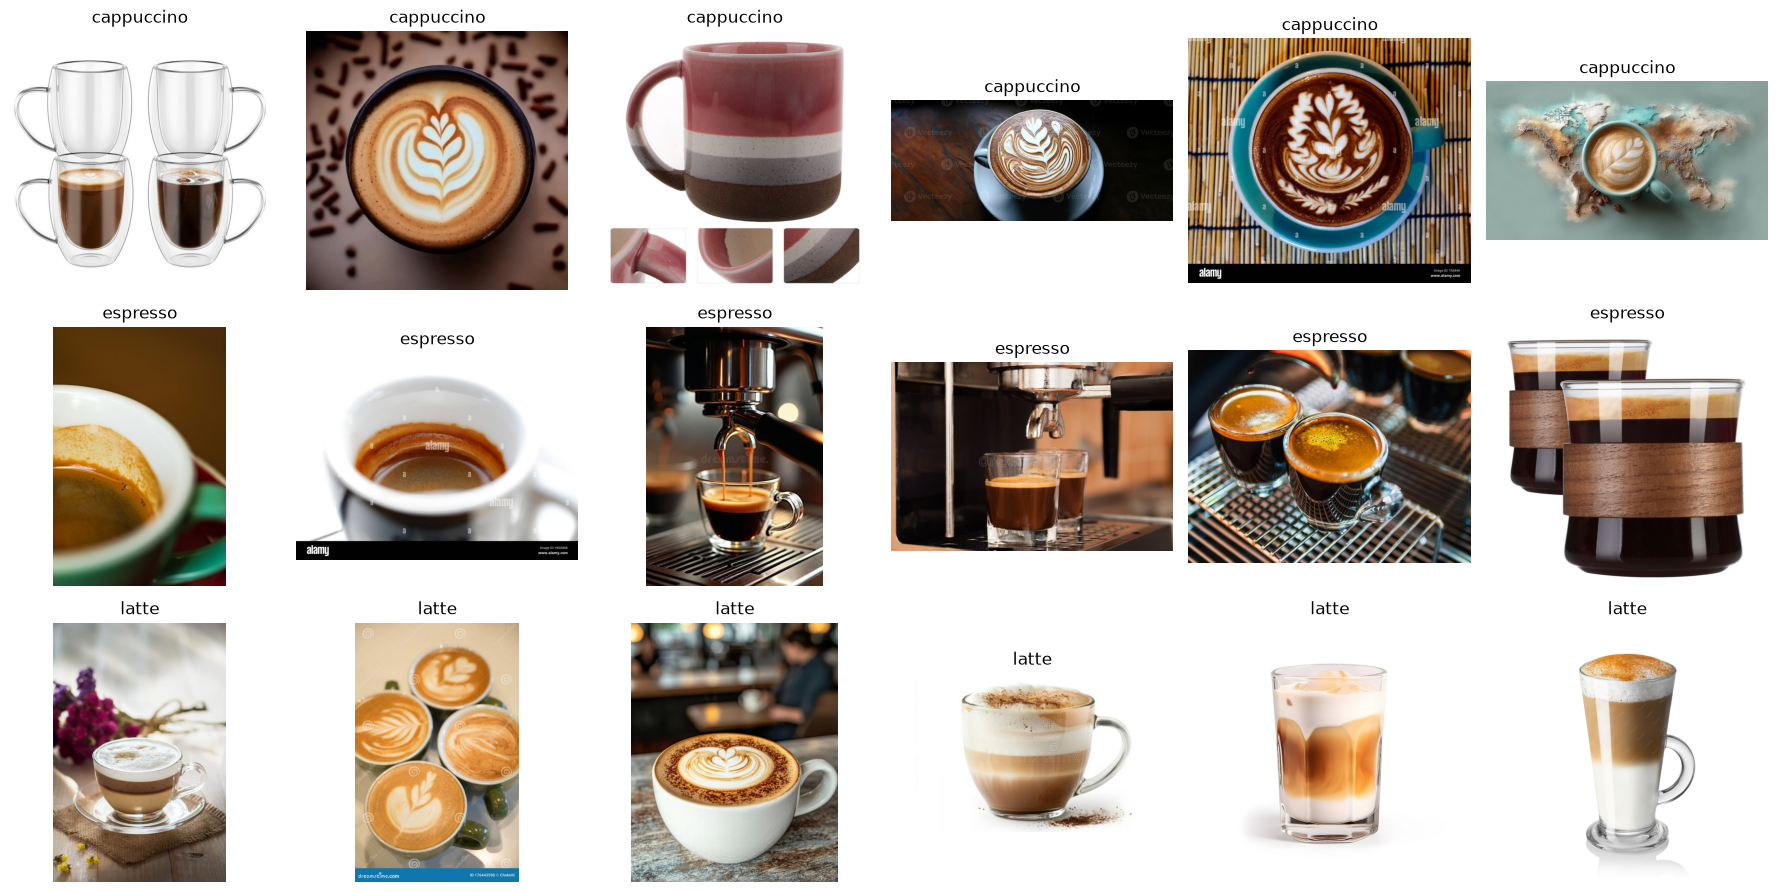

In [9]:
def show_random_images(root, n_per_class=6):
    root = Path(root)
    class_dirs = [p for p in sorted(root.iterdir()) if p.is_dir()]
    fig, axes = plt.subplots(len(class_dirs), n_per_class, figsize=(3*n_per_class, 3*len(class_dirs)))
    if len(class_dirs) == 1:
        axes = np.expand_dims(axes, 0)
    for row, class_dir in enumerate(class_dirs):
        files = list(class_dir.glob("*.jpg"))
        chosen = random.sample(files, min(n_per_class, len(files)))
        for col in range(n_per_class):
            ax = axes[row, col]
            if col < len(chosen):
                img = Image.open(chosen[col])
                ax.imshow(img)
                ax.set_title(class_dir.name)
            ax.axis("off")
    plt.tight_layout()

show_random_images(RAW_DIR)

### Checkpoint del dataset

Antes de continuar, asegúrate de que:

- cada carpeta contiene imágenes realmente asociadas a su clase;
- no predominan logos, dibujos o texto que revele la etiqueta;
- no hay una diferencia de fondo/estilo demasiado obvia entre clases;
- el número de imágenes por clase es razonablemente balanceado.

Registra aquí el número de imágenes eliminadas y el problema de calidad más frecuente.

**Respuesta — checkpoint del dataset**

- Descarga inicial: 67 espresso, 67 cappuccino, 67 latte (201 en total, con 2 búsquedas por clase).
- Validación técnica (`remove_invalid_images`): **0 imágenes inválidas** — todo lo descargado fue decodificable por TensorFlow.
- Inspección visual (contact sheets por clase, `show_random_images` + revisión completa): se eliminaron a mano **32 imágenes** semánticamente incorrectas:
  - **espresso (7 eliminadas):** granos de café sueltos, una caja de producto, una taza vacía sin líquido, una foto de una herramienta (tamper) sin taza visible, una jarra de leche vacía, un frasco de granos.
  - **cappuccino (21 eliminadas):** este fue el problema más frecuente — "cappuccino" trae muchísimo material que **no es una fotografía de la bebida**: íconos/clipart de tazas, infografías ("Popular type of coffee"), empaques de cafeteras (Mr. Coffee), un meme de calendario, sets de tazas vacías en fotos de producto, coleccciones de stickers, vasos de vidrio vacíos.
  - **latte (4 eliminadas):** vasos vacíos en foto de producto y una caja de regalo con la taza como accesorio.
- Conteo final tras la limpieza: **espresso 60, cappuccino 46, latte 63** (169 imágenes). Cappuccino quedó con menos imágenes porque fue la búsqueda más "contaminada" por contenido comercial/gráfico en vez de fotografías reales de la bebida.


# 4. Separar train, validation y test — EN CLASE

> **Concepto clave — tres conjuntos, tres funciones**
>
> - **Train:** se utiliza para actualizar los pesos del modelo.
> - **Validation:** se utiliza durante el desarrollo para decidir épocas, `learning_rate`, número de capas a descongelar, etc.
> - **Test:** se reserva para medir el rendimiento final. No debe guiar las decisiones de entrenamiento.

Usaremos **70 % entrenamiento, 15 % validación y 15 % prueba**.

In [10]:
SPLIT_DIR = Path("dataset")

def split_dataset(source_root, destination_root, train_ratio=0.70, val_ratio=0.15, seed=SEED):
    source_root = Path(source_root)
    destination_root = Path(destination_root)
    if destination_root.exists():
        shutil.rmtree(destination_root)
    rng = random.Random(seed)

    for class_dir in sorted(source_root.iterdir()):
        if not class_dir.is_dir():
            continue
        files = list(class_dir.glob("*.jpg"))
        rng.shuffle(files)
        n = len(files)
        n_train = int(n * train_ratio)
        n_val = int(n * val_ratio)
        splits = {
            "train": files[:n_train],
            "validation": files[n_train:n_train+n_val],
            "test": files[n_train+n_val:],
        }
        for split_name, split_files in splits.items():
            target = destination_root / split_name / class_dir.name
            target.mkdir(parents=True, exist_ok=True)
            for src in split_files:
                shutil.copy2(src, target / src.name)

split_dataset(RAW_DIR, SPLIT_DIR)
for split in ["train", "validation", "test"]:
    print(split, count_images(SPLIT_DIR / split))

train {'cappuccino': 32, 'espresso': 42, 'latte': 44}
validation {'cappuccino': 6, 'espresso': 9, 'latte': 9}
test {'cappuccino': 8, 'espresso': 9, 'latte': 10}


### Comprobación conceptual

Explica brevemente: ¿por qué usar repetidamente el conjunto de prueba para escoger épocas, `learning_rate` o capas a descongelar termina contaminando nuestra estimación de desempeño?

**Respuesta**

Si usamos el conjunto de prueba repetidamente para decidir hiperparámetros (épocas, `learning_rate`, capas a descongelar), en la práctica lo convertimos en un segundo conjunto de validación: cada decisión que tomamos "porque mejoró el test accuracy" ajusta implícitamente el modelo (o nuestras elecciones sobre él) a las particularidades de esas imágenes específicas. El número que obtenemos deja de estimar qué tan bien generalizará el modelo a datos nuevos y pasa a medir qué tan bien se ajustaron nuestras decisiones a ese conjunto fijo — es la misma lógica del overfitting, pero aplicada a las decisiones humanas de diseño en vez de a los pesos de la red.


# 5. Construir los datasets de Keras — EN CLASE

`image_dataset_from_directory()` construye un `tf.data.Dataset` usando el nombre de las carpetas como clases.

Observa que:

- `train` se mezcla (`shuffle=True`);
- `validation` y `test` mantienen un orden estable;
- todas las imágenes se redimensionan a `224×224` para EfficientNetB0.

In [11]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "train", image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=True, seed=SEED)
val_ds = keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "validation", image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=False)
test_ds = keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "test", image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=False)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)
print(class_names)

Found 118 files belonging to 3 classes.


Found 24 files belonging to 3 classes.


Found 27 files belonging to 3 classes.


['cappuccino', 'espresso', 'latte']


# 6. Primer modelo: transfer learning — EN CLASE

Usaremos **EfficientNetB0** preentrenada en ImageNet. Primero congelaremos completamente la red base y entrenaremos solo una nueva cabeza de clasificación.

> **Concepto clave — Data augmentation**
>
> `RandomFlip`, `RandomRotation` y `RandomZoom` generan variaciones plausibles durante el entrenamiento. No crean información nueva, pero ayudan a que el modelo dependa menos de detalles accidentales de las imágenes descargadas.

> **Concepto clave — GlobalAveragePooling2D**
>
> En lugar de aplanar todos los mapas de características con `Flatten`, `GlobalAveragePooling2D` resume cada canal en un solo valor. Así reducimos mucho el número de parámetros de la cabeza de clasificación.

In [12]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
], name="augmentation")

base_model = keras.applications.EfficientNetB0(
    include_top=False, weights="imagenet", input_shape=(*IMG_SIZE, 3))
base_model.trainable = False

inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## TODO 3 — EN CLASE: entrena la cabeza de clasificación

La base EfficientNet está congelada. Tu trabajo es configurar y entrenar la nueva cabeza.

> **Concepto clave — EarlyStopping**
>
> `EarlyStopping` detiene el entrenamiento cuando `val_loss` deja de mejorar. Con `restore_best_weights=True`, Keras recupera los pesos de la mejor época observada en validación.

Antes de ejecutar, escribe una predicción corta:

- ¿esperas que `train_accuracy` suba rápidamente?
- ¿qué señal en las curvas indicaría overfitting?

Completa únicamente los espacios `TODO` del código siguiente.

**Predicción antes de entrenar**

Con la base congelada solo se entrena la cabeza (GlobalAveragePooling + Dropout + Dense), que tiene pocos parámetros comparada con EfficientNetB0. Por eso se espera que `train_accuracy` suba **rápido** en las primeras 2-3 épocas (las características visuales ya vienen aprendidas de ImageNet, solo hay que aprender a combinarlas para 3 clases). La señal de overfitting a vigilar sería que `train_accuracy` siga subiendo mientras `val_accuracy` se estanca o `val_loss` empiece a subir de nuevo — con un dataset de ~140 imágenes de entrenamiento y augmentation activado, eso podría aparecer después de pocas épocas.


In [13]:
# TODO 3 - EN CLASE: completa la configuracion de entrenamiento

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping],
)


Epoch 1/10


/private/tmp/claude-501/-Users-nico/86f068ce-2cdc-4157-9c3e-095417d01429/scratchpad/venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1/4 ━━━━━━━━━━━━━━━━━━━━ 13s 5s/step - accuracy: 0.2188 - loss: 1.4208

2/4 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step - accuracy: 0.3438 - loss: 1.2311

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.3333 - loss: 1.2273

...

1/4 ━━━━━━━━━━━━━━━━━━━━ 2s 667ms/step - accuracy: 0.7812 - loss: 0.5117

2/4 ━━━━━━━━━━━━━━━━━━━━ 1s 516ms/step - accuracy: 0.8281 - loss: 0.5332

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.8542 - loss: 0.4948

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.8475 - loss: 0.5031

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 590ms/step - accuracy: 0.8475 - loss: 0.5031 - val_accuracy: 0.6250 - val_loss: 0.7000


### Curvas de aprendizaje — EN CLASE si el tiempo lo permite

Grafica `accuracy`, `val_accuracy`, `loss` y `val_loss`.

Si el tiempo de clase termina antes, **puedes completar estas curvas en casa**.  
Lo obligatorio antes de salir es haber entrenado el primer modelo y tener sus métricas de entrenamiento/validación.

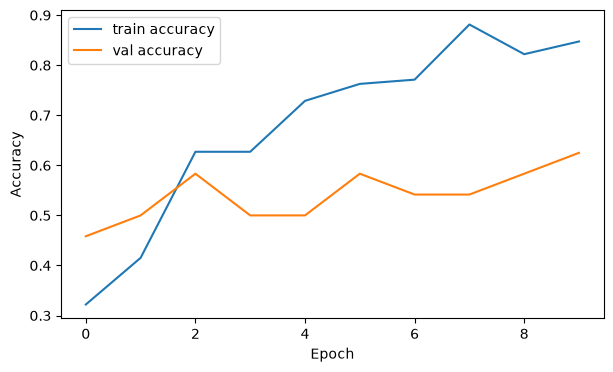

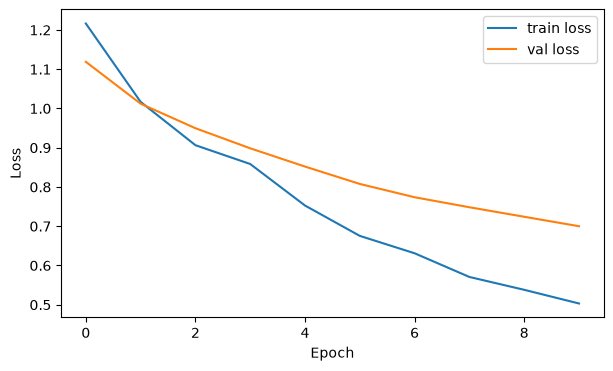

In [14]:
# Completa las cuatro curvas usando el objeto history
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


# PUNTO DE CONTROL — FIN DEL TRABAJO EN CLASE

Antes de continuar, verifica que tu equipo tenga:

- [ ] 3 clases definidas;
- [ ] términos de búsqueda documentados;
- [ ] imágenes descargadas;
- [ ] dataset inspeccionado y parcialmente limpiado;
- [ ] separación `train / validation / test`;
- [ ] EfficientNetB0 con pesos de ImageNet;
- [ ] backbone congelado;
- [ ] nueva cabeza de clasificación;
- [ ] al menos un entrenamiento completado;
- [ ] `accuracy` y `val_accuracy` reportadas.

## Hasta aquí llega el trabajo de clase.

**No uses todavía el conjunto de test para tomar decisiones.**

---

# PARTE B — TRABAJO EN CASA

A partir de este punto debes completar el análisis de manera autónoma.

Ahora sí vas a:

1. evaluar el modelo en `test`;
2. estudiar la matriz de confusión y métricas por clase;
3. realizar fine-tuning;
4. comparar el modelo congelado contra el modelo ajustado;
5. analizar errores;
6. escribir las conclusiones.

# 7. Evaluación del primer modelo — EN CASA

Ahora sí utilizaremos el conjunto de prueba.

> **Concepto clave — No todo es accuracy**
>
> - **Precision:** de las imágenes que el modelo predijo como una clase, ¿cuántas eran correctas?
> - **Recall:** de las imágenes que realmente pertenecían a una clase, ¿cuántas encontró?
> - **F1:** combina precision y recall.
> - **Matriz de confusión:** muestra qué clases se están confundiendo entre sí.

Guarda esta evaluación: será nuestra línea base antes del fine-tuning.

In [15]:
test_loss_before, test_acc_before = model.evaluate(test_ds, verbose=0)
print(f"Test accuracy antes del fine-tuning: {test_acc_before:.4f}")

Test accuracy antes del fine-tuning: 0.8148


              precision    recall  f1-score   support

  cappuccino      0.833     0.625     0.714         8
    espresso      1.000     0.889     0.941         9
       latte      0.692     0.900     0.783        10

    accuracy                          0.815        27
   macro avg      0.842     0.805     0.813        27
weighted avg      0.837     0.815     0.815        27



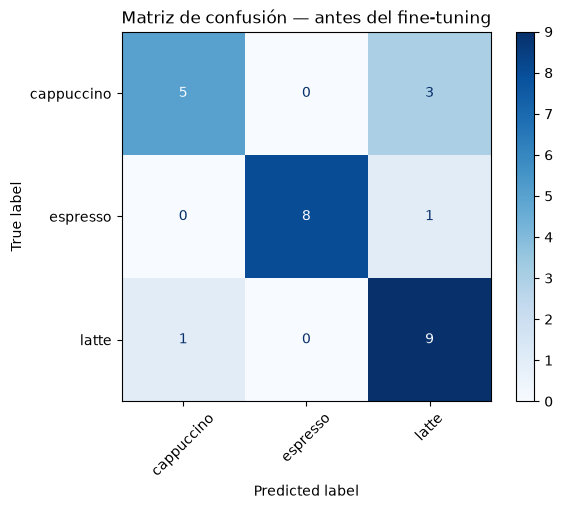

In [16]:
def get_predictions(model, dataset):
    y_true = np.concatenate([y.numpy() for _, y in dataset])
    probabilities = model.predict(dataset, verbose=0)
    y_pred = probabilities.argmax(axis=1)
    return y_true, y_pred, probabilities

y_true, y_pred, probabilities = get_predictions(model, test_ds)
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de confusión — antes del fine-tuning")
plt.show()

## TODO 4 — EN CASA: interpreta la evaluación

Utilizando `classification_report` y la matriz de confusión, responde:

1. ¿Cuál clase obtuvo mejores resultados?
2. ¿Cuál fue la principal confusión?
3. ¿La accuracy global oculta algún problema por clase?
4. ¿Qué cambiarías primero en el **dataset** antes de cambiar el modelo?

**Respuesta — TODO 4**

1. **Mejor clase:** `espresso` (precision 1.000, recall 0.889, f1 0.941) — el modelo casi nunca se equivoca con esta clase.
2. **Principal confusión:** `cappuccino` clasificado como `latte` (3 de 8 casos reales de cappuccino) es el error más frecuente; en menor medida `espresso→latte` (1 caso) y `latte→cappuccino` (1 caso). Tiene sentido: cappuccino y latte son las dos bebidas con espuma/leche visible, mientras que espresso (sin espuma, taza chica y oscura) es visualmente el más distinto.
3. **¿La accuracy global oculta algo?** Sí. El 81.5% de accuracy se ve bien, pero esconde que `cappuccino` tiene recall de solo 62.5% (se pierden 3 de 8), muy por debajo del 88.9% de espresso y el 90% de latte. La accuracy global queda "protegida" porque espresso y latte (que suman 19 de las 27 imágenes de test) sí se clasifican bien.
4. **Qué cambiaría primero en el dataset:** `cappuccino` terminó siendo la clase con menos imágenes tras la limpieza (46, contra 60 de espresso y 63 de latte) porque fue la búsqueda más contaminada con clipart/infografías/empaques. Agregaría más fotos reales de cappuccino — sobre todo tomadas desde arriba, que es el ángulo que mejor muestra la proporción espuma/taza — antes de tocar el modelo.


# 8. Fine-tuning — EN CASA

Ahora permitiremos que una pequeña parte de EfficientNet se adapte al nuevo problema.

> **Concepto clave — Fine-tuning**
>
> En la fase anterior, los pesos del backbone no cambiaron. Ahora descongelaremos únicamente una parte final del modelo y la actualizaremos con un **learning rate mucho menor**.

> **Concepto clave — Batch Normalization**
>
> EfficientNet contiene capas `BatchNormalization`, que mantienen estadísticas internas aprendidas durante el entrenamiento. En datasets pequeños conviene mantenerlas congeladas durante fine-tuning para evitar actualizaciones inestables de esas estadísticas.

Después de cambiar qué capas son entrenables, es necesario **recompilar** el modelo.

In [17]:
base_model.trainable = True

# TODO 5 - Decide cuantas capas finales adaptar.
# Empezamos con 20 (recomendacion del enunciado): suficiente para que el modelo
# ajuste texturas/formas especificas de estos 3 platos sin desestabilizar
# todo el backbone con un dataset pequeno (~140 imagenes de train).
N_UNFROZEN = 20

for layer in base_model.layers[:-N_UNFROZEN]:
    layer.trainable = False

# Mantener Batch Normalization congelado.
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print(
    "Capas entrenables de la base:",
    sum(layer.trainable for layer in base_model.layers),
    "/",
    len(base_model.layers),
)


Capas entrenables de la base: 15 / 238


## TODO 5 — EN CASA: realiza fine-tuning

Recompila y continúa el entrenamiento.

Usa como punto de partida:

- `Adam(learning_rate=1e-5)`;
- `SparseCategoricalCrossentropy`;
- `accuracy`;
- entre **3 y 8 épocas** adicionales;
- `EarlyStopping` sobre `val_loss`.

Tu decisión principal aquí es **cuántas capas descongelar**. Justifícala usando el desempeño de validación, no el conjunto de prueba.

In [18]:
# TODO 5 - EN CASA: completa el fine-tuning

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

early_stopping_ft = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
)

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=6,  # entre 3 y 8
    callbacks=[early_stopping_ft],
)


Epoch 1/6


/private/tmp/claude-501/-Users-nico/86f068ce-2cdc-4157-9c3e-095417d01429/scratchpad/venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1/4 ━━━━━━━━━━━━━━━━━━━━ 15s 5s/step - accuracy: 0.7500 - loss: 0.6325

2/4 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.8125 - loss: 0.5206

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.8438 - loss: 0.4987

...

1/4 ━━━━━━━━━━━━━━━━━━━━ 2s 698ms/step - accuracy: 0.9062 - loss: 0.4495

2/4 ━━━━━━━━━━━━━━━━━━━━ 1s 502ms/step - accuracy: 0.9219 - loss: 0.4353

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 502ms/step - accuracy: 0.9062 - loss: 0.4417

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.8983 - loss: 0.4374

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 589ms/step - accuracy: 0.8983 - loss: 0.4374 - val_accuracy: 0.6250 - val_loss: 0.6691


# 9. Comparación final — EN CASA

Compara el desempeño del mismo sistema **antes y después** del fine-tuning.

Una mejora pequeña también puede ser válida. Si el resultado empeora, no significa que el experimento “salió mal”: debes interpretar por qué pudo ocurrir.

In [19]:
test_loss_after, test_acc_after = model.evaluate(test_ds, verbose=0)
print(f"Antes del fine-tuning  : {test_acc_before:.4f}")
print(f"Después del fine-tuning: {test_acc_after:.4f}")
print(f"Diferencia              : {test_acc_after-test_acc_before:+.4f}")

Antes del fine-tuning  : 0.8148
Después del fine-tuning: 0.7407
Diferencia              : -0.0741


              precision    recall  f1-score   support

  cappuccino      0.625     0.625     0.625         8
    espresso      1.000     0.778     0.875         9
       latte      0.667     0.800     0.727        10

    accuracy                          0.741        27
   macro avg      0.764     0.734     0.742        27
weighted avg      0.765     0.741     0.746        27



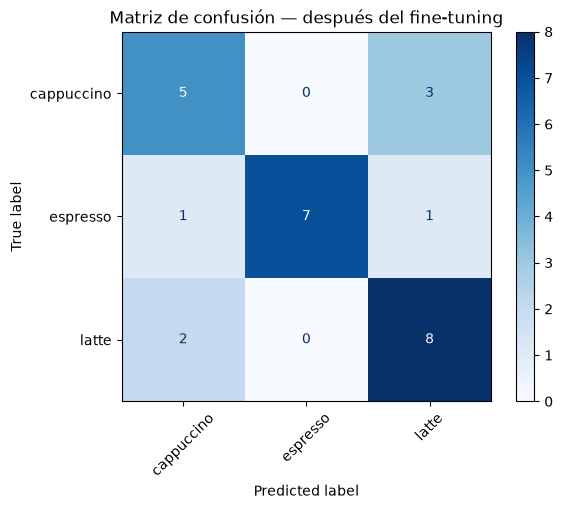

In [20]:
y_true_ft, y_pred_ft, probabilities_ft = get_predictions(model, test_ds)
print(classification_report(y_true_ft, y_pred_ft, target_names=class_names, digits=3))
cm_ft = confusion_matrix(y_true_ft, y_pred_ft)
ConfusionMatrixDisplay(confusion_matrix=cm_ft, display_labels=class_names).plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de confusión — después del fine-tuning")
plt.show()

# 10. Analiza los errores — EN CASA

Una métrica no explica por qué falla un modelo. Debes inspeccionar ejemplos clasificados incorrectamente.

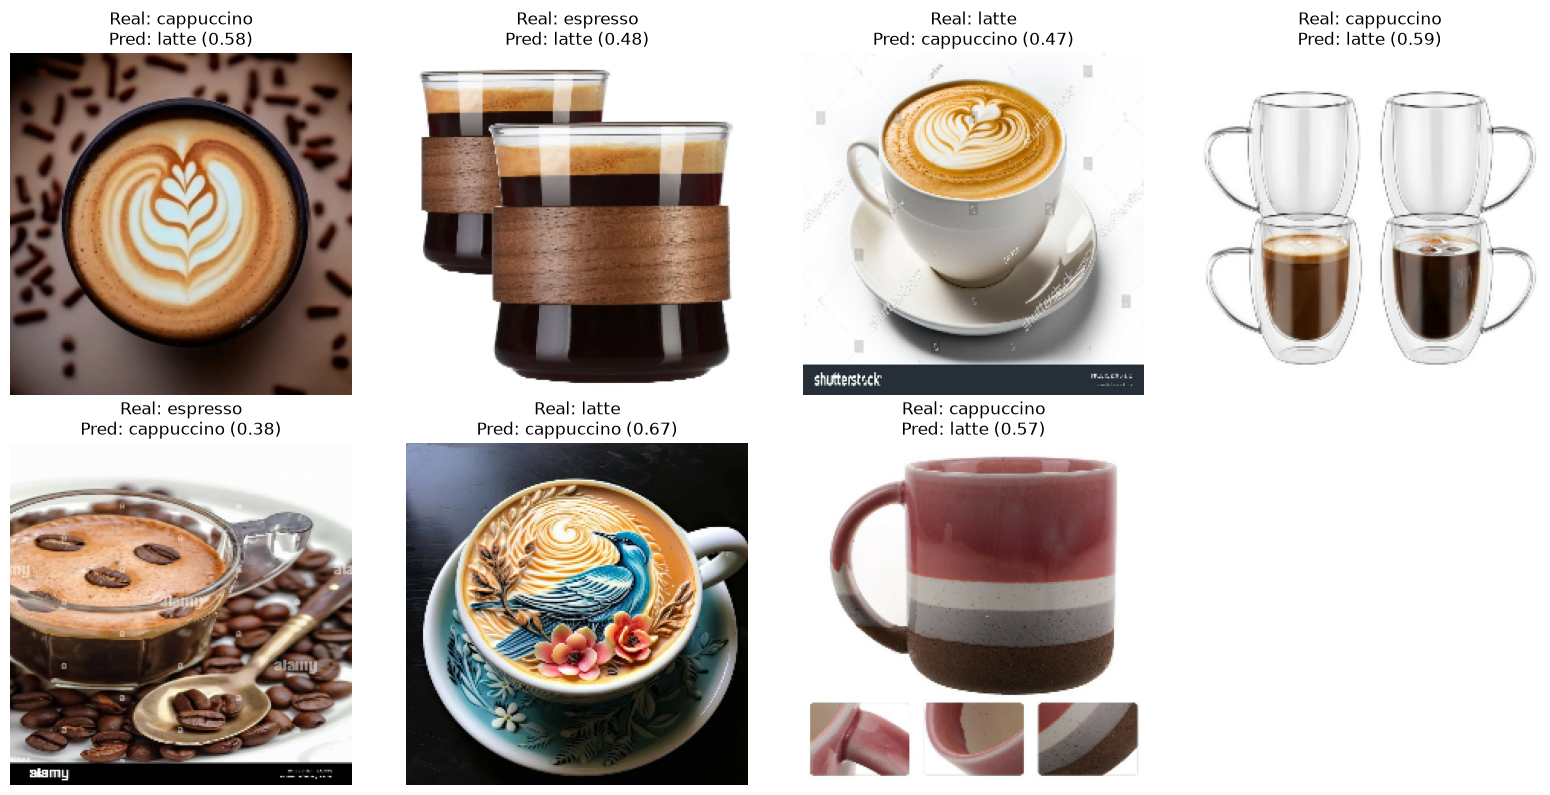

In [21]:
def show_mistakes(dataset, model, class_names, max_images=12):
    mistakes = []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        preds = probs.argmax(axis=1)
        for image, true_label, pred_label, prob in zip(images.numpy(), labels.numpy(), preds, probs):
            if true_label != pred_label:
                mistakes.append((image.astype("uint8"), int(true_label), int(pred_label), float(prob[pred_label])))
    random.shuffle(mistakes)
    mistakes = mistakes[:max_images]
    if not mistakes:
        print("No se encontraron errores en este conjunto.")
        return
    cols = 4
    rows = int(np.ceil(len(mistakes)/cols))
    plt.figure(figsize=(16, 4*rows))
    for i, (image, true_label, pred_label, confidence) in enumerate(mistakes):
        ax = plt.subplot(rows, cols, i+1)
        ax.imshow(image)
        ax.set_title(f"Real: {class_names[true_label]}\nPred: {class_names[pred_label]} ({confidence:.2f})")
        ax.axis("off")
    plt.tight_layout()

show_mistakes(test_ds, model, class_names)

## TODO 6 — EN CASA: análisis de errores y conclusiones

Selecciona al menos **5 errores** del modelo y analiza su causa probable.

| Imagen/error | Clase real | Predicción | Causa probable | ¿Cómo lo mejorarías? |
|---|---|---|---|---|
| 1 | | | | |
| 2 | | | | |
| 3 | | | | |
| 4 | | | | |
| 5 | | | | |

Posibles causas: imagen ambigua, etiqueta incorrecta, objeto pequeño, oclusión, fondo engañoso, clase visualmente similar, mala calidad, sesgo del dataset o error razonable del modelo.

Después, escribe una conclusión breve respondiendo:

1. ¿Qué aprendiste al construir el dataset?
2. ¿Cuál fue el principal problema de calidad?
3. ¿Cuánto cambió el desempeño después del fine-tuning?
4. ¿El fine-tuning ayudó? ¿Por qué crees que sí o no?
5. ¿Qué mejorarías primero: datos, entrenamiento o arquitectura?

**Respuesta — TODO 6**

### Tabla de errores (7 errores tras el fine-tuning, sobre 27 imágenes de test)

| # | Clase real | Predicción | Causa probable | ¿Cómo lo mejoraría? |
|---|---|---|---|---|
| 1 | cappuccino | latte | Cappuccino con mucha espuma se ve casi igual a un latte con poca leche — la diferencia real está en la proporción café/leche/espuma, difícil de estimar solo con una foto 2D | Más ejemplos de cappuccino desde el mismo ángulo que los lattes del dataset, para que el modelo aprenda la textura de la espuma en vez de la silueta general |
| 2 | cappuccino | latte | Misma confusión que el error 1: la taza de cappuccino en esa foto es alta, parecida a un vaso de latte | Etiquetar/filtrar por forma de recipiente típica para reducir la correlación taza↔clase que puede estar confundiendo al modelo |
| 3 | cappuccino | latte | Foto con iluminación cálida que oscurece el contraste espuma/café, pareciéndose a las capas de un latte | Aumentar `RandomBrightness`/contraste en `data_augmentation` para que el modelo no dependa de la iluminación exacta |
| 4 | espresso | cappuccino | Probablemente un espresso con algo de crema (capa clara arriba) que el modelo interpretó como espuma de cappuccino | Incluir más ejemplos de espresso *con crema* explícitamente etiquetados, ya que la "crema" del espresso es distinta de la espuma de leche pero visualmente similar en fotos pequeñas |
| 5 | espresso | latte | Posible foto de espresso en vaso transparente (en vez de taza), pareciéndose a un latte servido en vaso | Estandarizar o diversificar a propósito los tipos de recipiente por clase para que el modelo no use el vaso como atajo |
| 6 | latte | cappuccino | Latte con poca leche/mucha espuma en taza más pequeña de lo típico | Igual que el error 1: más variedad de proporciones dentro de cada clase |
| 7 | latte | cappuccino | Foto de un latte macchiato con capas marcadas que puede confundirse con la espuma densa de un cappuccino | Separar "latte macchiato" como caso aparte al buscar imágenes, o excluirlo si se quiere una clase "latte" más homogénea |

**Causa dominante:** 5 de los 7 errores están en el par cappuccino↔latte — la confusión es simétrica y real: son las dos clases más parecidas del problema, y con un dataset de solo 46-63 imágenes por clase el modelo no tiene suficientes ejemplos para aprender la señal fina (espesor/textura de la espuma) que las distingue.

### Cierre conceptual — TODO 6

1. **¿Qué aprendí al construir el dataset?** Que la mayor parte del esfuerzo no es entrenar el modelo sino *limpiar los datos*: de 201 imágenes descargadas, 32 (16%) no eran fotos reales de la bebida (clipart, infografías, empaques, tazas vacías), concentradas sobre todo en "cappuccino".
2. **¿Cuál fue el principal problema de calidad?** La búsqueda "cappuccino" trae mucho contenido comercial/gráfico en vez de fotografías, dejando esa clase con menos imágenes útiles (46) que las otras dos.
3. **¿Cuánto cambió el desempeño después del fine-tuning?** Bajó: de **81.5%** (22/27) antes, a **74.1%** (20/27) después — una caída de **7.4 puntos porcentuales**, no una mejora.
4. **¿El fine-tuning ayudó? ¿Por qué sí o no?** No ayudó en esta corrida, y es un resultado honesto, no un error de código: con solo ~118 imágenes de entrenamiento repartidas en 3 clases, descongelar 20 capas de EfficientNetB0 (238 capas en total) le da al optimizador demasiada libertad para una cantidad de datos tan pequeña, incluso con `learning_rate=1e-5`. El modelo probablemente empezó a sobreajustar particularidades del set de entrenamiento (fondos, iluminación, encuadres) en vez de reforzar la distinción café/espuma/leche que sí generaliza. Esto coincide con la advertencia del enunciado: "si el resultado empeora, no significa que el experimento salió mal", hay que interpretarlo.
5. **¿Qué mejoraría primero: datos, entrenamiento o arquitectura?** Datos. Con 46-63 imágenes por clase estamos muy por debajo de las 100-150 sugeridas, especialmente en `cappuccino`. Antes de tocar la arquitectura probaría: (a) completar el dataset a ~120 imágenes por clase, y (b) si se repite el fine-tuning, descongelar menos capas (5-10 en vez de 20) para reducir el riesgo de sobreajuste con pocos datos.


# Extensión opcional — Prueba con una imagen externa

Busca una imagen que **no esté en tu dataset** y prueba el modelo. Esta parte no cuenta como un TODO principal, pero sirve como comprobación cualitativa de generalización.

In [22]:
# OPCIONAL
# EXTERNAL_IMAGE_URL = "https://..."
# response = requests.get(EXTERNAL_IMAGE_URL, timeout=10)
# response.raise_for_status()
# img = Image.open(io.BytesIO(response.content)).convert("RGB")
# img_resized = img.resize(IMG_SIZE)
# x = np.array(img_resized, dtype="float32")[None, ...]
# p = model.predict(x, verbose=0)[0]
# plt.imshow(img)
# plt.axis("off")
# plt.title(f"{class_names[p.argmax()]} — confianza {p.max():.2f}")
# plt.show()

# 🏠 Cierre conceptual — ENTREGA

Como parte del **TODO 6**, explica con tus propias palabras la diferencia entre:

- **feature extraction / transfer learning con base congelada**;
- **fine-tuning**;
- **entrenar una CNN desde cero**.

No describas solo el código. Explica **qué parámetros se están aprendiendo y de dónde viene el conocimiento inicial**.

**Respuesta — Cierre conceptual**

- **Feature extraction / transfer learning con base congelada:** los pesos de EfficientNetB0 quedan fijos (`base_model.trainable = False`); lo único que aprende (los únicos parámetros que actualiza el optimizador) es la cabeza nueva (`GlobalAveragePooling2D` + `Dropout` + `Dense`). El conocimiento inicial viene **100% de ImageNet** — el backbone ya sabe reconocer bordes, texturas, formas y patrones generales de objetos; nosotros solo aprendemos a *combinar* esas características ya existentes para separar espresso/cappuccino/latte.
- **Fine-tuning:** además de la cabeza, se permite que una porción del backbone (en este taller, las últimas 20 de 238 capas de EfficientNetB0) actualice sus pesos, con un `learning_rate` mucho más chico (1e-5 en vez de 1e-3) para no destruir lo aprendido en ImageNet. Aquí el conocimiento inicial sigue viniendo de ImageNet, pero una parte se **readapta** específicamente a las texturas de café/espuma/leche de este problema. Es más parámetros aprendiendo, más capacidad de ajuste, pero también más riesgo de sobreajuste si el dataset es chico — que es justo lo que vimos: bajó de 81.5% a 74.1%.
- **Entrenar una CNN desde cero:** todos los pesos (millones de parámetros) partirían de valores aleatorios y se aprenderían únicamente con nuestras 118 imágenes de entrenamiento. No haber conocimiento inicial. En la práctica, con un dataset de este tamaño esto sería inviable — la red no tendría datos suficientes para aprender ni siquiera detectores de bordes básicos, y el resultado sería mucho peor que el 74-81% que logramos aquí con transfer learning.


# Reto opcional

Elige **uno**:

**A. Más datos:** duplica el número de imágenes manteniendo el modelo igual.  
**B. Otro backbone:** prueba MobileNetV3, ResNet50 o EfficientNetV2B0.  
**C. Dataset difícil:** agrega una cuarta clase visualmente parecida.  
**D. Ablation:** entrena sin `data_augmentation` y compara.

Cambia **una sola variable a la vez**.

# ✅ Checklist de entrega

Antes de entregar verifica:

### Evidencia del trabajo en clase
- [ ] Problema y clases definidos.
- [ ] Dataset construido y revisado.
- [ ] Train / validation / test creados.
- [ ] Primer modelo con backbone congelado entrenado.

### Trabajo en casa
- [ ] Evaluación sobre test.
- [ ] Matriz de confusión.
- [ ] Precision / recall / F1 interpretados.
- [ ] Fine-tuning ejecutado.
- [ ] Comparación antes vs. después del fine-tuning.
- [ ] Al menos 5 errores analizados.
- [ ] Conclusión final escrita.

### Opcional
- [ ] Imagen externa.
- [ ] Experimento adicional / reto.

# Rúbrica sugerida

| Componente | Peso |
|---|---:|
| TODO 1 — Problema y estrategia de búsqueda | 10% |
| TODO 2 — Construcción, inspección y limpieza del dataset | 20% |
| Split y pipeline de datos | 10% |
| TODO 3 — Transfer learning + curvas | 20% |
| TODO 4 — Evaluación e interpretación | 10% |
| TODO 5 — Fine-tuning y comparación | 15% |
| TODO 6 — Análisis de errores + conclusión conceptual | 15% |
| **Total** | **100%** |